<a href="https://colab.research.google.com/github/ori23s/airline-satisfaction/blob/main/AirlinePassengerSatisfaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro to AI - Airline Passenger Satisfaction Project
## **Authors**: Yonatan Barak and Ori Setty
## Project Overview

This project focuses on predicting airline passenger satisfaction.

* **Target Mapping**:
  * `1`: Neutral or Dissatisfied
  * `0`: Satisfied
* **Positive Class**: Dissatisfied (Class 1)
* **Model Selection Metric**: Validation ROC AUC
* **Operating Threshold Policy**: Choose the threshold on the validation set that maximizes the F1 score for class 1, then use the same threshold on the test set.
* **Date of Submission**: September 30, 2025

**Note**: Probability outputs refer to P(class 1), which is the probability of dissatisfaction.

## Import Relevant Libraries

Here are the libraries we will import for this project:

*   **Core Utilities**: `pandas`, `numpy` for data manipulation.
*   **Visualization Tools**: `matplotlib`, `seaborn` for creating plots.
*   **Scikit-learn**: For modeling, metrics, and preprocessing.
*   **Imbalanced-learn**: For handling class imbalance with SMOTE and pipelines.
*   **TensorFlow/Keras**: For building neural networks.
*   **KerasTuner**: For neural network hyperparameter tuning.

In [ ]:
# Install Keras Tuner for Neural Network Hyperparameter Tuning to be done in the future.
%pip install -q -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.7 MB/s eta 0:00:00


In [ ]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score, roc_curve, PrecisionRecallDisplay, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer


# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


# Distributions for hyperparameter search
from scipy.stats import randint, loguniform

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# KerasTuner
import keras_tuner as kt


Mounted at /content/drive


## Load and Explore the Dataset

This section loads the airline passenger satisfaction data and performs a first pass of exploratory checks. The goal is to understand structure, spot issues, and document choices that influence preprocessing.

Here's what we'll do:

1.  **Load the data**: Read the `airline_passenger_satisfaction.csv` file into a pandas DataFrame.
2.  **Drop non-predictive identifiers**: Remove any pure IDs, for example ID, so they do not leak noise into the model.
3.  **Initial Inspection**: Show `data.shape()`, `data.head()`, and `data.info()` to confirm column names, types, and basic structure.
4.  **Descriptive Statistics**: Get a summary of the central tendency, dispersion, and shape of the dataset's numerical columns using `data.describe()`.
5.  **Handle Rating Zeros/Nulls**: Find Null values and set rating zeros to Null in order to not take into account invalid values when training our models
6.  **Target Variable Distribution**: Examine the distribution of the target variable (`Satisfaction`) to understand the class balance.

First 5 rows of the dataset:



,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,Male,48,First-time,Business,Business,821,2,5.00,3.00,3.00,...,3.00,5.00,2.00,5.00,5.00,5.00,3.00,5.00,5,Neutral or Dissatisfied
1,Female,35,Returning,Business,Business,821,26,39.00,2.00,2.00,...,5.00,4.00,5.00,5.00,3.00,5.00,2.00,5.00,5,Satisfied
2,Male,41,Returning,Business,Business,853,0,0.00,4.00,4.00,...,3.00,5.00,3.00,5.00,5.00,3.00,4.00,3.00,3,Satisfied
3,Male,50,Returning,Business,Business,1905,0,0.00,2.00,2.00,...,5.00,5.00,5.00,4.00,4.00,5.00,2.00,5.00,5,Satisfied
4,Female,49,Returning,Business,Business,3470,0,1.00,3.00,3.00,...,3.00,4.00,4.00,5.00,4.00,3.00,3.00,3.00,3,Satisfied


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  129880 non-null  object 
 1   Age                                     129880 non-null  int64  
 2   Customer Type                           129880 non-null  object 
 3   Type of Travel                          129880 non-null  object 
 4   Class                                   129880 non-null  object 
 5   Flight Distance                         129880 non-null  int64  
 6   Departure Delay                         129880 non-null  int64  
 7   Arrival Delay                           129487 non-null  float64
 8   Departure and Arrival Time Convenience  123199 non-null  float64
 9   Ease of Online Booking                  124198 non-null  float64
 10  Check-in Service             

,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.00,129880.00,129880.00,129487.00,123199.00,124198.00,129879.00,126800.00,129879.00,129875.00,129879.00,129282.00,129866.00,129748.00,129875.00,125964.00,129862.00,129880.00
mean,39.43,1190.32,14.71,15.09,3.22,2.88,3.31,3.33,2.98,3.38,3.44,3.37,3.29,3.21,3.64,2.81,3.36,3.63
std,15.12,997.45,38.07,38.47,1.39,1.30,1.27,1.27,1.28,1.29,1.32,1.30,1.31,1.33,1.18,1.26,1.33,1.18
min,7.00,31.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,27.00,414.00,0.00,0.00,2.00,2.00,3.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,3.00,2.00,2.00,3.00
50%,40.00,844.00,0.00,0.00,3.00,3.00,3.00,4.00,3.00,4.00,4.00,4.00,3.00,3.00,4.00,3.00,4.00,4.00
75%,51.00,1744.00,12.00,13.00,4.00,4.00,4.00,4.00,4.00,4.00,5.00,4.00,4.00,4.00,5.00,4.00,4.00,5.00
max,85.00,4983.00,1592.00,1584.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


Dataset shape: (129880, 23)

Value counts for 'Satisfaction' column:
Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64


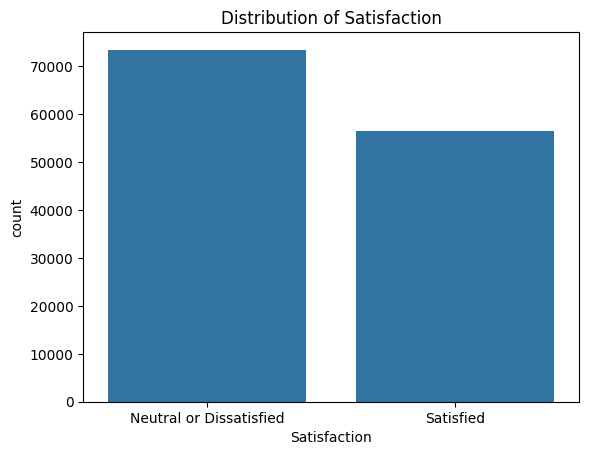

In [ ]:
# Load the dataset
path = 'airline_passenger_satisfaction.csv'
data = pd.read_csv(path)

# Remove the 'ID' column as it has no value in our code
data = data.drop('ID', axis=1)

# Columns where 0 means "not applicable"
rating_cols = [
    "Departure and Arrival Time Convenience",
    "Ease of Online Booking",
    "Check-in Service",
    "Online Boarding",
    "Gate Location",
    "On-board Service",
    "Seat Comfort",
    "Leg Room Service",
    "Cleanliness",
    "Food and Drink",
    "In-flight Service",
    "In-flight Wifi Service",
    "In-flight Entertainment",
    "Baggage Handling",
]

# Replace 0s with NaN for these rating columns
data[rating_cols] = data[rating_cols].replace(0, np.nan)

# Set pandas display option to suppress scientific notation and limit float precision
pd.options.display.float_format = '{:.2f}'.format

# Display the first five rows
print("First 5 rows of the dataset:\n")
display(data.head())

# Get basic information about the dataset
print("Dataset Info:\n")
data.info()

# Get descriptive statistics
print("Descriptive Statistics:\n")
display(data.describe())

print(f"Dataset shape: {data.shape}\n")
print("Value counts for 'Satisfaction' column:")
print(data['Satisfaction'].value_counts())

sns.countplot(x='Satisfaction', data=data)
plt.title("Distribution of Satisfaction")
plt.show()

Based on the exploration above, we observed:

* The dataset contains 129880 entries and 23 columns (after removing the 'ID' column).
* There are missing values in the `Arrival Delay` column and zero ratings that we will regard as null in many more.
* The dataset includes both numerical and categorical features.
* There is a class imbalance in the target variable (`Satisfaction`), with 'Neutral or Dissatisfied' having more entries than 'Satisfied'.

## Data Preprocessing

Based on our initial exploration, we need to preprocess the data before feeding it into machine learning models. This involves several steps to ensure the data is clean, in the correct format, and suitable for modeling.

The key preprocessing steps we will perform are:

1.  **Encode Categorical Features:** Convert categorical variables such as 'Gender', 'Customer Type', 'Type of Travel', and 'Class' into a numerical format using one-hot encoding.
2.  **Target Mapping**: Map the target to integers early: 1 = Neutral or Dissatisfied (positive class), 0 = Satisfied.
3.  **Split Data**: Divide the data into training (70%), validation (15%), and test (15%) sets, ensuring stratification to maintain the proportion of 'Satisfied' and 'Neutral or Dissatisfied' cases.
4.  **Handle Missing Values**:
    Some service ratings use 0 as “not applicable”. After converting those zeros to NaN, impute training medians for all missing values, calculate the medians on the train set and use it on all data.
5.  **Scale Numerical Features**: Standardize numerical features like 'Age', 'Flight Distance', 'Departure Delay', and 'Arrival Delay' to ensure they are on a similar scale.
6.  **Handle Class Imbalance**: Address the class imbalance in the 'Satisfaction' column using techniques like SMOTE *after* splitting the data to avoid data leakage.

In [ ]:
# Turn categorical variables into numerical values using getdummies()
categorical_columns = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Map data as: 1 = Neutral/Dissatisfied, 0 = Satisfied
y = data['Satisfaction'].map({'Neutral or Dissatisfied': 1, 'Satisfied': 0}).astype(int)

# Separate Features (X) and Target (y)
X = data.drop('Satisfaction', axis=1)

# First split: 70% train, 30% temp (which will be validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Second split: split the 30% temp into half (15% validation, 15% test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Fill missing data with training medians.

missing_cols = [
    "Departure and Arrival Time Convenience",
    "Ease of Online Booking",
    "Check-in Service",
    "Online Boarding",
    "Gate Location",
    "On-board Service",
    "Seat Comfort",
    "Leg Room Service",
    "Cleanliness",
    "Food and Drink",
    "In-flight Service",
    "In-flight Wifi Service",
    "In-flight Entertainment",
    "Arrival Delay",]

train_medians = X_train[missing_cols].median()
for df in (X_train, X_val, X_test):
    df[missing_cols] = df[missing_cols].fillna(train_medians)


# Scale Numerical Features
numerical_cols = ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience',
                  'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service',
                  'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service',
                  'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling']

scaler = StandardScaler()

# Save a copy of unscaled training data
X_train_unscaled = X_train.copy(deep=True)
X_val_unscaled = X_val.copy(deep=True)
X_test_unscaled = X_test.copy(deep=True)
# Fit the scaler ONLY on the training data to avoid data leakage
scaler.fit(X_train[numerical_cols])

# Transform the train, validation, and test sets using the fitted scaler
X_train[numerical_cols] = scaler.transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


# Verification
print("Data Shapes")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print("\n Processed Training Data (X_train) Head ")
display(X_train.head())

# Initialize SMOTE using KNN
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
print(f"Shape of training data before SMOTE: {X_train.shape}")
print(f"Class distribution before SMOTE:\n{y_train.value_counts()}")

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nShape of training data after SMOTE: {X_train_resampled.shape}")
print(f"Class distribution after SMOTE:\n{y_train_resampled.value_counts()}")

Data Shapes
X_train shape: (90916, 23)
X_val shape: (19482, 23)
X_test shape: (19482, 23)

 Processed Training Data (X_train) Head 


,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,...,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Gender_Male,Customer Type_Returning,Type of Travel_Personal,Class_Economy,Class_Economy Plus
101897,0.70,0.99,0.06,-0.08,-0.90,-0.70,-1.03,-1.87,-0.76,-1.07,...,1.35,-1.39,-0.66,-1.01,-1.38,False,True,False,False,False
79710,2.02,-0.43,1.34,1.50,1.32,0.09,-0.24,1.32,1.58,-1.07,...,-0.16,-1.39,0.15,-1.01,-1.38,False,True,True,True,False
100959,0.50,-0.05,-0.38,-0.26,1.32,0.87,0.54,1.32,-1.55,1.26,...,1.35,1.16,0.15,1.23,1.16,False,True,True,True,False
75973,0.50,-0.97,-0.38,-0.39,-0.16,0.09,-0.24,-1.07,0.02,1.26,...,-0.91,1.16,0.15,1.23,1.16,True,True,False,False,False
43256,-0.76,-0.66,-0.38,-0.39,1.32,0.09,-0.24,-0.28,0.80,-1.07,...,-0.16,-1.39,0.15,-0.26,-0.53,True,False,False,True,False


Shape of training data before SMOTE: (90916, 23)
Class distribution before SMOTE:
Satisfaction
1    51416
0    39500
Name: count, dtype: int64

Shape of training data after SMOTE: (102832, 23)
Class distribution after SMOTE:
Satisfaction
1    51416
0    51416
Name: count, dtype: int64


## Machine Learning Models

With preprocessing complete, we will train models to predict passenger dissatisfaction (positive class, class 1). We will report probabilities as P(class 1) and use the validation set to choose an operating threshold that maximizes F1 for class 1, then apply the same threshold on the test set.

We will begin by training each model with base hyperparameters to establish a baseline performance. Following this, we will perform hyperparameter tuning to potentially improve the models' performance.

Here are the models we will run:

*   **Logistic Regression**: A strong linear baseline.
*   **Random Forest**: An ensemble of decision trees that captures non-linear patterns.
*   **Keras Neural Network**: A small feed-forward model for comparison.

Here is the plan for handling imbalance:

*   **Baselines**: train on the original training split with class weighting.
*   **SMOTE path**: Use SMOTE on the training data only, and for tuning place SMOTE inside cross-validation with an imbalanced-learn Pipeline.

Here is the evaluation plan:

*   **Validation**: AUC, F1, precision, recall at the chosen threshold, plus a concise comparison table.


### Baseline Models

To begin our modeling phase, we will train several baseline machine learning models. These initial models will be trained withr simple settings to establish a performance reference point. The goal is to quickly understand how well basic versions of different algorithms perform on our preprocessed data before investing time in hyperparameter tuning. We will handle class imbalances using both SMOTE and class weiighting.

#### Logistic Regression

Logistic Regression is a fundamental linear classification algorithm. It models the probability that a given input point belongs to a certain class using the logistic function. Despite being a linear model, it often serves as a strong and efficient baseline for many classification tasks, particularly on tabular data like ours. We will evaluate its performance using AUC and classification metrics.

**Imbalance handling**: we will try both approaches, each in its own run:

*   SMOTE applied to the training data only
*   Class weighting on the original training split,


Using SMOTE to handle Class Imbalance:


Logistic Regression Evaluation on Validation Set
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      8464
           1       0.91      0.88      0.90     11018

    accuracy                           0.88     19482
   macro avg       0.88      0.88      0.88     19482
weighted avg       0.88      0.88      0.88     19482

ROC-AUC Score: 0.9530

Confusion Matrix:


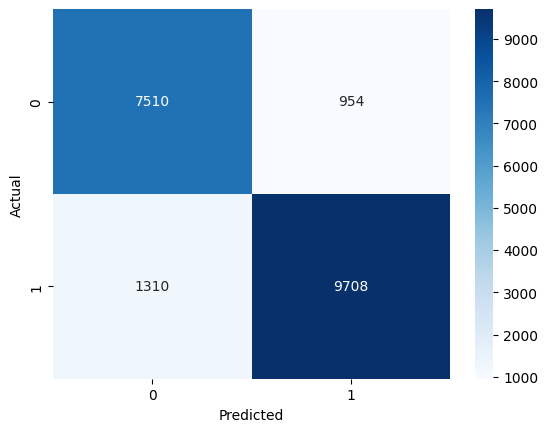

In [ ]:
#Initialize the model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
# Train the model
log_reg.fit(X_train_resampled, y_train_resampled)

y_pred_proba_lr = log_reg.predict_proba(X_val)[:, 1]

y_pred_lr = (y_pred_proba_lr >= 0.5).astype(int)

print("Logistic Regression Evaluation on Validation Set")
print("Classification Report:")
print(classification_report(y_val, y_pred_lr))

auc_score_lr = roc_auc_score(y_val, y_pred_proba_lr)
print(f"ROC-AUC Score: {auc_score_lr:.4f}\n")

print("Confusion Matrix:")
cm_lr = confusion_matrix(y_val, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Using class weighting to handle imbalance:

Logistic Regression Evaluation on Validation Set
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      8464
           1       0.91      0.88      0.90     11018

    accuracy                           0.88     19482
   macro avg       0.88      0.88      0.88     19482
weighted avg       0.89      0.88      0.88     19482

ROC-AUC Score: 0.9530

Confusion Matrix:


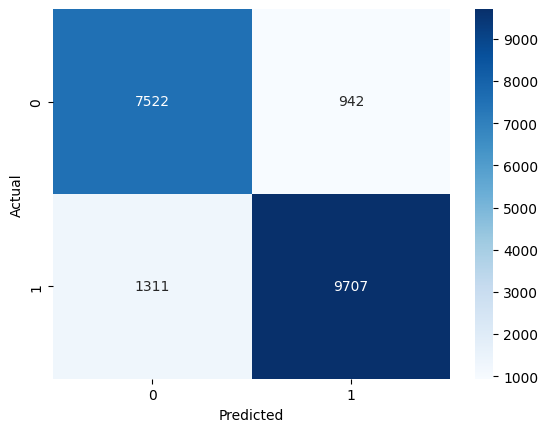

In [ ]:
# Initialize the model
log_reg = LogisticRegression(random_state=42, class_weight = 'balanced', max_iter=1000)
# Train the model
log_reg.fit(X_train, y_train)

y_pred_proba_lr = log_reg.predict_proba(X_val)[:, 1]

y_pred_lr = (y_pred_proba_lr >= 0.5).astype(int)

print("Logistic Regression Evaluation on Validation Set")
print("Classification Report:")
print(classification_report(y_val, y_pred_lr))

auc_score_lr = roc_auc_score(y_val, y_pred_proba_lr)
print(f"ROC-AUC Score: {auc_score_lr:.4f}\n")
# Confusion Matrix
print("Confusion Matrix:")
cm_lr = confusion_matrix(y_val, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Both options produced almost identical results, we will use SMOTE when returning to the algorithm.





#### Random Forest

Random Forest is an ensemble learning method that builds multiple decision trees during training and merges their predictions to improve accuracy and control overfitting. It's a versatile algorithm that can capture complex non-linear relationships in the data and is generally robust to noise and outliers. We will train a baseline Random Forest model and evaluate its performance.

Just as with Logistic Regression we will try both methods to handle imbalance.

Using SMOTE to handle Class Imbalance:

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      8464
           1       0.95      0.97      0.96     11018

    accuracy                           0.96     19482
   macro avg       0.96      0.95      0.95     19482
weighted avg       0.96      0.96      0.96     19482

ROC-AUC: 0.9913817452348983

Confusion Matrix:


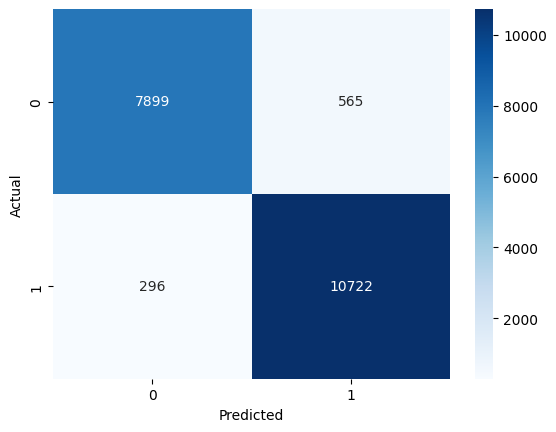

In [ ]:
# Initialize the model
random_forest = RandomForestClassifier(random_state=42)
# Train the model
random_forest.fit(X_train_resampled, y_train_resampled)

y_pred_rf = random_forest.predict(X_val)
print(classification_report(y_val, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val, random_forest.predict_proba(X_val)[:,1]))
# Confusion Matrix
print("\nConfusion Matrix:")
rf_matrix = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(rf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Using Class Weights to handle Class Imbalance:

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      8464
           1       0.95      0.98      0.96     11018

    accuracy                           0.96     19482
   macro avg       0.96      0.95      0.95     19482
weighted avg       0.96      0.96      0.95     19482

ROC-AUC: 0.991192841212575

Confusion Matrix:


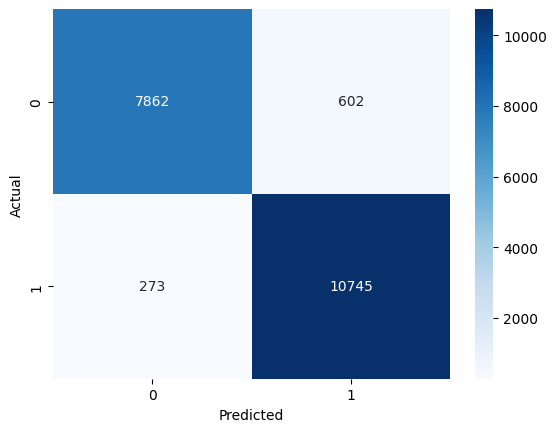

In [ ]:
# Initialize the model
random_forest = RandomForestClassifier(class_weight = "balanced", random_state=42)
# Train the model
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_val)
print(classification_report(y_val, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val, random_forest.predict_proba(X_val)[:,1]))
# Confusion Matrix
print("\nConfusion Matrix:")
rf_matrix = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(rf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In an identical fashion to Logistic Regression, the two options did not produce different results, the ROC-AUC score is essentially identical between the two and so  we will continue using SMOTE and not balanced class weights.

#### Keras Model

Here, we will build a Keras neural network. To find the most robust version and demonstrate how to prevent overfitting, we will build and compare three different configurations:

*   **Naive Model**: A baseline network with no regularization.
*   **Dropout Model:** Our main model, using Dropout and Early Stopping.
*   **L2 Regularization Model:** An alternative approach using L2 weight regularization.

This will allow us to compare the effectiveness of each technique

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Overfitting Demonstration Graph ---


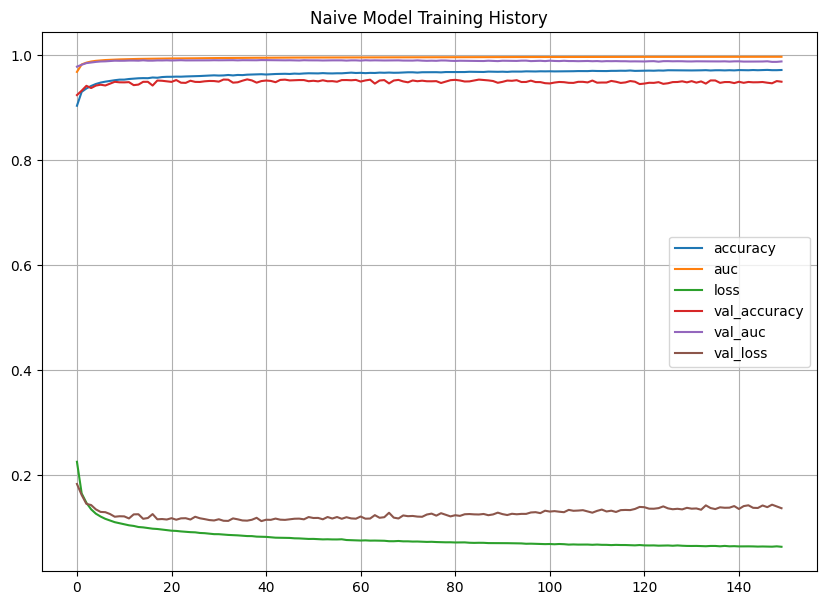

Naive Model Evaluation on Validation Set
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      8464
           1       0.95      0.96      0.96     11018

    accuracy                           0.95     19482
   macro avg       0.95      0.95      0.95     19482
weighted avg       0.95      0.95      0.95     19482

ROC-AUC Score: 0.9908

Confusion Matrix:


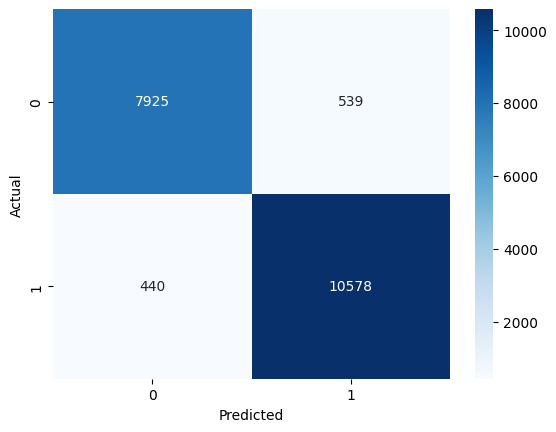

In [ ]:
# Naive Model for Overfitting Demonstration

# Define the model(no dropout or regularization)
model_naive = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_naive.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# Train for many epochs without early stopping to show overfitting
history_naive = model_naive.fit(
    X_train_resampled, y_train_resampled,
    epochs=150,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0
)

# show results
print("--- Overfitting Demonstration Graph ---")
pd.DataFrame(history_naive.history).plot(figsize=(10, 7))
plt.title("Naive Model Training History")
plt.grid(True)
plt.show()

# Evaluation of the Naive Model
print("Naive Model Evaluation on Validation Set")
y_pred_proba_naive = model_naive.predict(X_val)
y_pred_naive = (y_pred_proba_naive > 0.5).astype("int32")

print("Classification Report:")
print(classification_report(y_val, y_pred_naive))

auc_score_naive = roc_auc_score(y_val, y_pred_proba_naive)
print(f"ROC-AUC Score: {auc_score_naive:.4f}")

print("\nConfusion Matrix:")
cm_naive = confusion_matrix(y_val, y_pred_naive)
sns.heatmap(cm_naive, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1607/1607 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8541 - auc: 0.9282 - loss: 0.3280 - val_accuracy: 0.9224 - val_auc: 0.9767 - val_loss: 0.1898
Epoch 2/150
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9159 - auc: 0.9744 - loss: 0.2019 - val_accuracy: 0.9325 - val_auc: 0.9818 - val_loss: 0.1661
Epoch 3/150
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9262 - auc: 0.9796 - loss: 0.1796 - val_accuracy: 0.9372 - val_auc: 0.9839 - val_loss: 0.1537
Epoch 4/150
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9302 - auc: 0.9825 - loss: 0.1657 - val_accuracy: 0.9391 - val_auc: 0.9854 - val_loss: 0.1466
Epoch 5/150
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9307 - auc: 0.9832 - loss: 0.1624 - val_accuracy: 0.9416 - val_auc: 0.9859 - val_loss: 0.1414
Epoch 6/150
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9348 - auc: 0.9844 - loss: 0.1552 - val_accuracy: 0.9442 - val_auc: 0.9871 - val_loss: 0.1368
Epoch 7/150
1607/1607 ━━━━━━━━━━

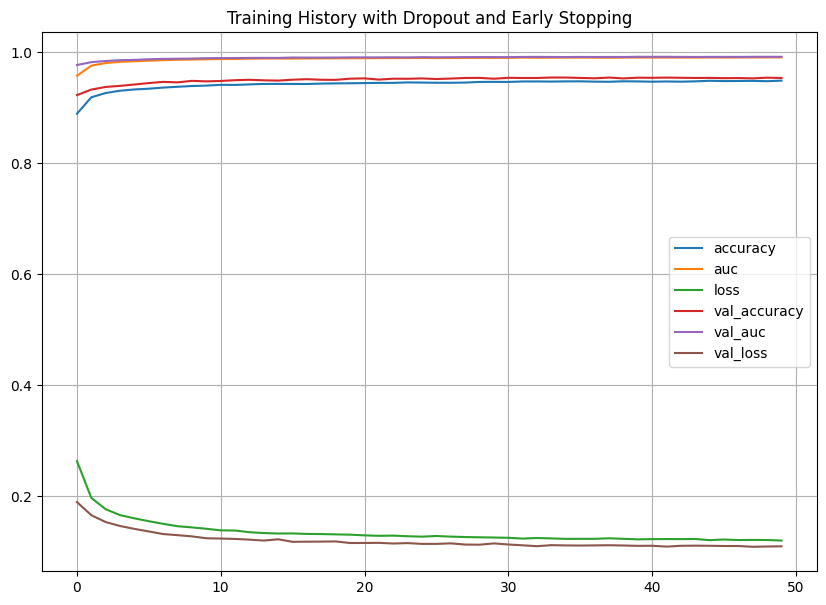


Dropout Model Evaluation on Validation Set
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      8464
           1       0.95      0.97      0.96     11018

    accuracy                           0.95     19482
   macro avg       0.96      0.95      0.95     19482
weighted avg       0.95      0.95      0.95     19482

ROC-AUC Score: 0.9916

Confusion Matrix:


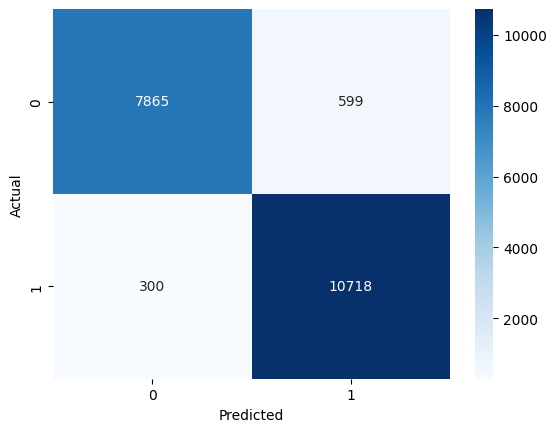

In [ ]:
# Model with Dropout and Early Stopping

# Define the model with Dropout layers
model_dropout = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_resampled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# use Early Stopping
early_stopping = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)

# Train the model
history_dropout = model_dropout.fit(
    X_train_resampled, y_train_resampled,
    epochs=150,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

# Evaluation
print("Dropout Model Training History")
pd.DataFrame(history_dropout.history).plot(figsize=(10, 7))
plt.title("Training History with Dropout and Early Stopping")
plt.grid(True)
plt.show()

print("\nDropout Model Evaluation on Validation Set")
y_pred_proba_dropout = model_dropout.predict(X_val)
y_pred_dropout = (y_pred_proba_dropout > 0.5).astype("int32")

print("Classification Report:")
print(classification_report(y_val, y_pred_dropout))

auc_score_dropout = roc_auc_score(y_val, y_pred_proba_dropout)
print(f"ROC-AUC Score: {auc_score_dropout:.4f}")

print("\nConfusion Matrix:")
cm_dropout = confusion_matrix(y_val, y_pred_dropout)
sns.heatmap(cm_dropout, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1607/1607 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8617 - auc: 0.9335 - loss: 0.5778 - val_accuracy: 0.9184 - val_auc: 0.9739 - val_loss: 0.2564
Epoch 2/150
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9183 - auc: 0.9750 - loss: 0.2537 - val_accuracy: 0.9228 - val_auc: 0.9769 - val_loss: 0.2366
Epoch 3/150
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9217 - auc: 0.9778 - loss: 0.2361 - val_accuracy: 0.9199 - val_auc: 0.9786 - val_loss: 0.2301
Epoch 4/150
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9236 - auc: 0.9794 - loss: 0.2253 - val_accuracy: 0.9231 - val_auc: 0.9798 - val_loss: 0.2252
Epoch 5/150
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9262 - auc: 0.9802 - loss: 0.2194 - val_accuracy: 0.9257 - val_auc: 0.9787 - val_loss: 0.2172
Epoch 6/150
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9257 - auc: 0.9798 - loss: 0.2176 - val_accuracy: 0.9246 - val_auc: 0.9800 - val_loss: 0.2140
Epoch 7/150
1607/1607 ━━━━━━━━━━━

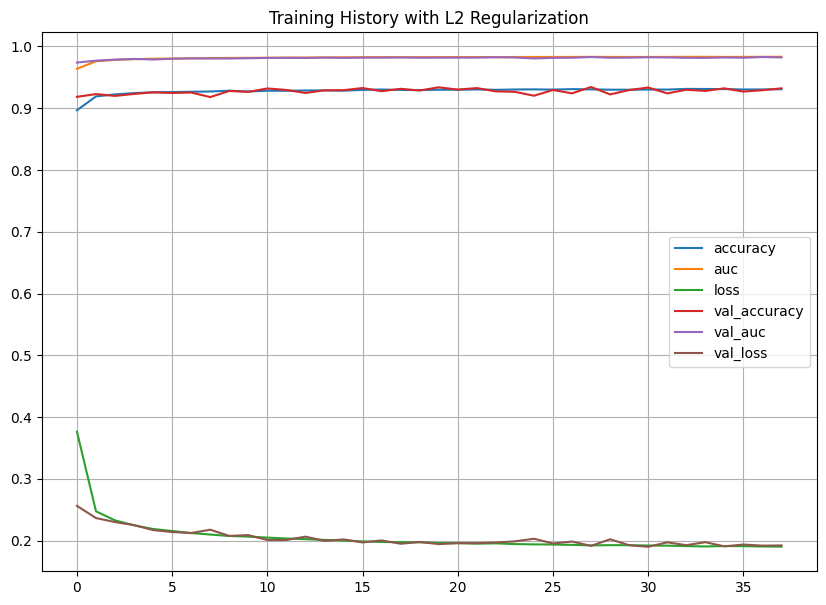


L2 Model Evaluation on Validation Set
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      8464
           1       0.92      0.96      0.94     11018

    accuracy                           0.93     19482
   macro avg       0.94      0.93      0.93     19482
weighted avg       0.93      0.93      0.93     19482

ROC-AUC Score: 0.9828

Confusion Matrix:


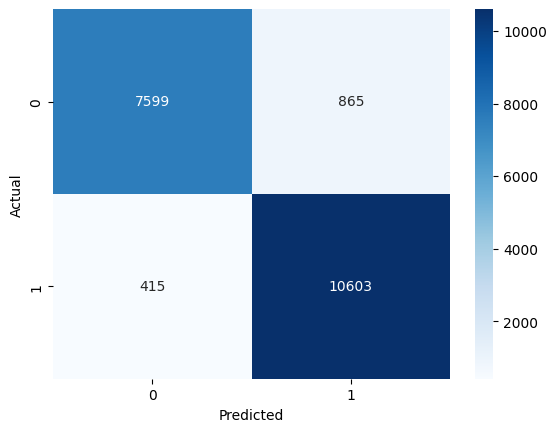

In [ ]:

# Model with L2 Regularization

# Define the model with L2 regularization on Dense layers
model_l2 = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train_resampled.shape[1],)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# 3. Train the model
history_l2 = model_l2.fit(
    X_train_resampled, y_train_resampled,
    epochs=150,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)],
    verbose=1
)

# Evaluation of the L2 Model
print("\L2 Model Training History")
pd.DataFrame(history_l2.history).plot(figsize=(10, 7))
plt.title("Training History with L2 Regularization")
plt.grid(True)
plt.show()

print("\nL2 Model Evaluation on Validation Set")
y_pred_proba_l2 = model_l2.predict(X_val)
y_pred_l2 = (y_pred_proba_l2 > 0.5).astype("int32")

print("Classification Report:")
print(classification_report(y_val, y_pred_l2))

auc_score_l2 = roc_auc_score(y_val, y_pred_proba_l2)
print(f"ROC-AUC Score: {auc_score_l2:.4f}")

print("\nConfusion Matrix:")
cm_l2 = confusion_matrix(y_val, y_pred_l2)
sns.heatmap(cm_l2, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Based on the evaluation of the three Keras models:

* The **Naive Model** showed signs of overfitting (as seen in the training history plot) but achieved a high ROC-AUC on the validation set.
* The **L2 Regularization Model** showed less overfitting than the Naive model but had a lower ROC-AUC on the validation set compared to both the Naive and Dropout models. This is probably a case of "underfitting".
* The **Dropout Model** with Early Stopping effectively prevented overfitting and achieved the highest ROC-AUC score on the validation set, performing slightly better than the Naive model in terms of AUC and offering better generalization as indicated by the training history.

Therefore, we will proceed with the **Dropout Model** for hyperparameter tuning and final evaluation as it provided the best balance of performance and generalization.

### Hyperparameter Tuning

Hyperparameter tuning is the process of finding the optimal set of hyperparameters for a machine learning model. Hyperparameters are parameters that are not learned from the data during training, but are set before training begins. Examples include the learning rate, the number of layers in a neural network, or the number of trees in a random forest.

Tuning these hyperparameters can significantly impact a model's performance. We often use techniques like Grid Search or Random Search to explore different combinations of hyperparameters and identify the best performing set based on a chosen evaluation metric (e.g., accuracy, AUC). In our case we will use ROC-AUC.I

#### Logistic Regression

Now that we've seen the base performance of the Logistic Regression model, we will tune its hyperparameters to potentially improve its performance. The main hyperparameters for Logistic Regression are:

*   `C` (regularization strength)
*   `penalty` (the type of regularization - 'l1', 'l2', or 'elasticnet')
*   `l1_ratio` (only used if penalty='elasticnet')

We will use `RandomizedSearchCV` with `StratifiedKFold` cross-validation to efficiently search through a defined distribution of these hyperparameters and find the combination that yields the best cross-validated ROC AUC score. Tuning is done via a Pipeline that applies StandardScaler and SMOTE inside each CV fold, so we fit the search on the original (unscaled) training split.

In [ ]:
preprocess = ColumnTransformer(
    transformers=[("num", StandardScaler(), numerical_cols)],
    remainder="passthrough"   # keep all other columns unchanged
)

# Pipeline: SMOTE happens inside each training fold only
pipe = Pipeline([
    ("prep", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("logreg", LogisticRegression(solver="saga", max_iter=5000, random_state=42))
])


# Hyperparameter search space
param_dist = {
    "logreg__C": loguniform(1e-3, 1e3),                 # regularization strength
    "logreg__penalty": ["l1", "l2", "elasticnet"],      # type of penalty
    "logreg__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0]     # only used if penalty='elasticnet'
}

# Stratified CV preserves class balance across folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized search for efficiency
logreg_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Run the search on unscaled data
logreg_search.fit(X_train_unscaled, y_train)

# Best parameters and CV AUC
print("Best hyperparameters:", logreg_search.best_params_)
print("Best cross-validated AUC:", round(logreg_search.best_score_, 4))

# Final tuned model
best_log_reg = logreg_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best hyperparameters: {'logreg__C': np.float64(0.1767016940294795), 'logreg__l1_ratio': 1.0, 'logreg__penalty': 'elasticnet'}
Best cross-validated AUC: 0.9532


Next, we'll find the optimal threshold:

Validation AUC: 0.9531
Best threshold (F1): 0.40

Classification Report:
               precision    recall  f1-score   support

           0      0.882     0.855     0.868      8464
           1      0.891     0.912     0.901     11018

    accuracy                          0.887     19482
   macro avg      0.886     0.883     0.885     19482
weighted avg      0.887     0.887     0.887     19482



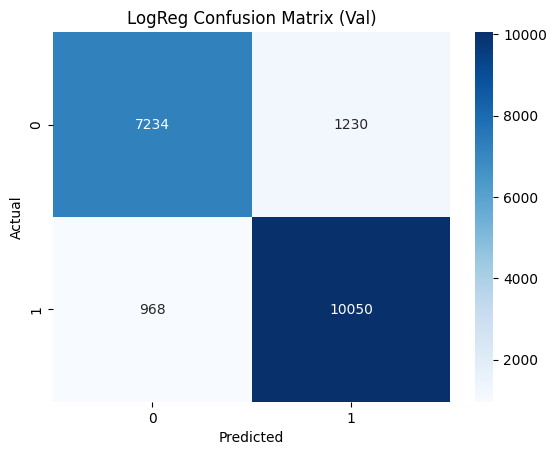

In [ ]:
# Evaluate best model on validation; pick best threshold by F1
y_val_proba = best_log_reg.predict_proba(X_val_unscaled)[:, 1]
val_auc = roc_auc_score(y_val, y_val_proba)

# Search threshold that maximizes F1 on validation
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = [f1_score(y_val, (y_val_proba >= t).astype(int)) for t in thresholds]
best_t = thresholds[int(np.argmax(f1_scores))]

y_val_pred = (y_val_proba >= best_t).astype(int)

print(f"Validation AUC: {val_auc:.4f}")
print(f"Best threshold (F1): {best_t:.2f}")
print("\nClassification Report:\n", classification_report(y_val, y_val_pred, digits=3))

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("LogReg Confusion Matrix (Val)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


We will now define the Logistic Regression model directly using the best hyperparameters identified during the RandomizedSearchCV so that we don't need to rerun the hyperparameter search each time.

In [ ]:
log_reg_best_params = {
    "solver": "saga", "max_iter": 5000, "random_state": 42,
    "penalty": "elasticnet", "C": np.float64(0.1767016940294795), "l1_ratio": 1.0
}
preprocess = ColumnTransformer(
    [("num", StandardScaler(), numerical_cols)],
    remainder="passthrough")
pipe = Pipeline([
    ("prep", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("logreg", LogisticRegression(**log_reg_best_params))
])

pipe.fit(X_train_unscaled, y_train)
best_log_reg = pipe.named_steps["logreg"]

We will also check the level of convergence for our model.

In [ ]:
print("Converged iterations (max over classes):", int(max(best_log_reg.n_iter_)))
print("Max_iter:", best_log_reg.max_iter, "| Solver:", best_log_reg.solver, "| tol:", best_log_reg.tol)

Converged iterations (max over classes): 29
Max_iter: 5000 | Solver: saga | tol: 0.0001


#### Random Forest

Now that we've seen the base performance of the Random Forest model, we will tune its hyperparameters to potentially improve its performance. The main hyperparameters for Logistic Regression are:

*   `n_estimators` (number of trees)
*   `max_depth` (maximum tree depth)
*   `max_features` (features considered at each split)
*   `min_samples_split` (minimum samples to split a node)
*   `min_samples_leaf` (minimum samples in a leaf)

We will use `RandomizedSearchCV` with `StratifiedKFold` cross-validation to efficiently search through a defined distribution of these hyperparameters and find the combination that yields the best cross-validated ROC AUC score. Tuning is done via a Pipeline that applies StandardScaler and SMOTE inside each CV fold, so we fit the search on the original (unscaled) training split.

We'll use the best hyperparameters found by the search and manually input them to evaluate the tuned model and find the optimal threshold on the validation set. This approach allows us to easily access the tuned model for future use without rerunning the lengthy hyperparameter search.

In [ ]:
# CELL — Random Forest Hyperparameter Tuning with RandomizedSearchCV

preprocess = ColumnTransformer(
    transformers=[("num", StandardScaler(), numerical_cols)],
    remainder="passthrough"   # keep all other columns unchanged
)

# Pipeline: SMOTE happens inside each training fold only
pipe = Pipeline([
    ("prep", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Hyperparameter search space
param_dist = {
    "rf__n_estimators": randint(100, 500),       # number of trees
    "rf__max_depth": randint(3, 30),             # maximum depth of trees
    "rf__min_samples_split": randint(2, 20),     # min samples to split a node
    "rf__min_samples_leaf": randint(1, 20),      # min samples in a leaf
    "rf__max_features": ["sqrt", "log2", None]   # features considered at each split
}

# Stratified CV preserves class balance across folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized search for efficiency
rf_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Run the search
rf_search.fit(X_train_unscaled, y_train)

# Best parameters and CV AUC
print("Best hyperparameters:", rf_search.best_params_)
print("Best cross-validated AUC:", round(rf_search.best_score_, 4))

# Final tuned model
best_rf = rf_search.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best hyperparameters: {'rf__max_depth': 24, 'rf__max_features': None, 'rf__min_samples_leaf': 3, 'rf__min_samples_split': 2, 'rf__n_estimators': 326}
Best cross-validated AUC: 0.992


Optimal Threshold Search:

Validation AUC: 0.9920
Best threshold (F1): 0.44

Classification Report:
               precision    recall  f1-score   support

           0      0.972     0.927     0.949      8464
           1      0.946     0.980     0.962     11018

    accuracy                          0.957     19482
   macro avg      0.959     0.953     0.956     19482
weighted avg      0.957     0.957     0.956     19482



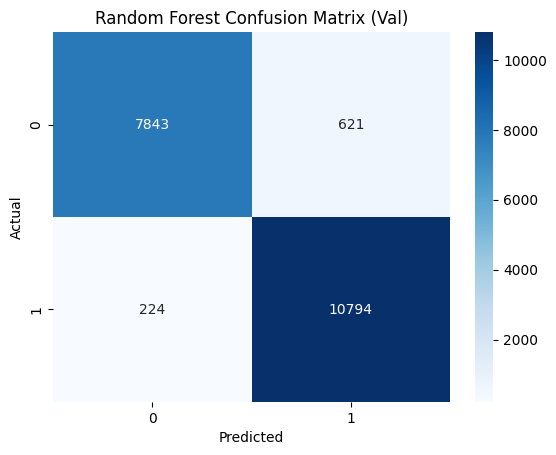

In [ ]:
# Evaluate best model on validation; pick best threshold by F1
y_val_proba = best_rf.predict_proba(X_val_unscaled)[:, 1]
val_auc = roc_auc_score(y_val, y_val_proba)

# Search threshold that maximizes F1 on validation
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = [f1_score(y_val, (y_val_proba >= t).astype(int)) for t in thresholds]
best_t = thresholds[int(np.argmax(f1_scores))]

y_val_pred = (y_val_proba >= best_t).astype(int)

print(f"Validation AUC: {val_auc:.4f}")
print(f"Best threshold (F1): {best_t:.2f}")
print("\nClassification Report:\n", classification_report(y_val, y_val_pred, digits=3))

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix (Val)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()


We will now define the Random Forest model directly using the best hyperparameters identified during the `RandomizedSearchCV`. This approach allows us to work with the optimized model configuration without needing to rerun the hyperparameter search every time, making it easier to evaluate and utilize for predictions.

In [ ]:
rf_best_params = {
    "max_depth": 24, "max_features": None, "min_samples_leaf": 3,
    "min_samples_split": 2, "n_estimators": 326, "random_state": 42, "n_jobs": -1
}
preprocess = ColumnTransformer(
    [("num", StandardScaler(), numerical_cols)],
    remainder="passthrough")
pipe = Pipeline([
    ("prep", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(**rf_best_params))
])

pipe.fit(X_train_unscaled, y_train)
best_rf = pipe.named_steps["rf"]

#### Keras Model

Let's tune the hyperparameters of the Keras neural network model to optimize its performance. We will focus on tuning the following hyperparameters:

*   **`units1`**: Number of neurons in the first dense layer.
*   **`units2`**: Number of neurons in the second dense layer.
*   **`dropout`**: Dropout rate for the dropout layers.
*   **`l2`**: L2 regularization strength for the dense layers.
*   **`lr`**: Learning rate for the Adam optimizer.

We will use `BayesianOptimization` with Early Stopping and ReduceLROnPlateau callbacks to efficiently search for the best combination of these hyperparameters based on the validation ROC AUC.

In [ ]:
# Keras hyperparameter tuning (Dropout Model)
def build_model(hp: kt.HyperParameters):
    units1  = hp.Int("units1", 32, 256, step=32)
    units2  = hp.Int("units2", 16, 256, step=16)
    dropout = hp.Float("dropout", 0.0, 0.6, step=0.1)
    l2w     = hp.Choice("l2", [0.0, 1e-5, 1e-4, 1e-3])
    lr      = hp.Choice("lr", [1e-2, 5e-3, 1e-3, 5e-4, 1e-4])

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_resampled.shape[1],)),
        tf.keras.layers.Dense(units1, activation='relu',
                              kernel_regularizer=tf.keras.regularizers.l2(l2w)),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(units2, activation='relu',
                              kernel_regularizer=tf.keras.regularizers.l2(l2w)),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                 tf.keras.metrics.AUC(name='auc')]
    )
    return model

tuner = kt.BayesianOptimization(
    build_model,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=25,
    num_initial_points=6,
    directory="kt_airline",
    project_name="keras_dense_tuning",
    overwrite=True
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=8, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc", mode="max", factor=0.5, patience=4, verbose=0
)

tuner.search(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.get_best_models(1)[0]
print("Best HP:", best_hp.values)

val_loss, val_acc, val_auc = best_model.evaluate(X_val, y_val, verbose=0)
print(f"Validation — AUC: {val_auc:.4f}, Acc: {val_acc:.4f}, Loss: {val_loss:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best HP: {'units1': 224, 'units2': 128, 'dropout': 0.2, 'l2': 0.0001, 'lr': 0.005}
Validation — AUC: 0.9935, Acc: 0.9595, Loss: 0.1125


Optimal Threshold:

Validation AUC: 0.9937
Best threshold (F1): 0.350 | Best F1: 0.965

Classification Report (Validation):
              precision    recall  f1-score   support

   Satisfied       0.98      0.92      0.95      8464
Dissatisfied       0.94      0.99      0.97     11018

    accuracy                           0.96     19482
   macro avg       0.96      0.96      0.96     19482
weighted avg       0.96      0.96      0.96     19482



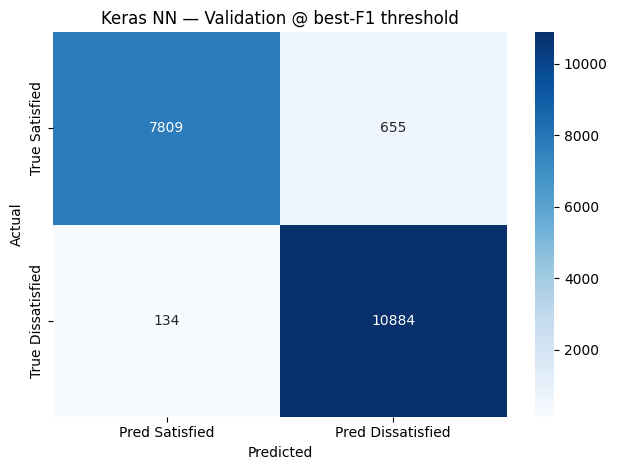

In [ ]:
# Evaluate tuned Keras model on validation; pick threshold by F1
y_val_proba = best_model.predict(X_val, verbose=0).ravel()  # probs for class 1
val_auc = roc_auc_score(y_val, y_val_proba)

# Search threshold that maximizes F1 on validation
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = [f1_score(y_val, (y_val_proba >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(f1_scores))
best_t = float(thresholds[best_idx])

y_val_pred = (y_val_proba >= best_t).astype(int)

print(f"Validation AUC: {val_auc:.4f}")
print(f"Best threshold (F1): {best_t:.3f} | Best F1: {f1_scores[best_idx]:.3f}\n")
print("Classification Report (Validation):")
print(classification_report(y_val, y_val_pred,
                            target_names=['Satisfied','Dissatisfied']))

cm = confusion_matrix(y_val, y_val_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Pred Satisfied','Pred Dissatisfied'],
            yticklabels=['True Satisfied','True Dissatisfied'])
plt.title("Keras NN — Validation @ best-F1 threshold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

# Save for test-time reuse
best_threshold_keras = best_t


In [ ]:
# --- Keras Dropout model rebuilt with Best HP and evaluated on validation ---

# Best HP from tuner:
hp_units1, hp_units2 = 224, 128
hp_dropout = 0.2
hp_l2 = 1e-4
hp_lr = 5e-3



# Define the model with your tuned hyperparameters
model_dropout = Sequential([
    Dense(hp_units1, activation='relu',
          kernel_regularizer=l2(hp_l2),
          input_shape=(X_train_resampled.shape[1],)),
    Dropout(hp_dropout),
    Dense(hp_units2, activation='relu',
          kernel_regularizer=l2(hp_l2)),
    Dropout(hp_dropout),
    Dense(1, activation='sigmoid')
])

# Compile with tuned learning rate
model_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Early Stopping on validation AUC
early_stopping = EarlyStopping(monitor='val_auc', mode='max',
                               patience=10, restore_best_weights=True)

# Train
history_dropout = model_dropout.fit(
    X_train_resampled, y_train_resampled,
    epochs=150, batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=0
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


We'll check how long it took to converge:

In [ ]:
epochs_run = len(history_dropout.epoch)
best_epoch = int(np.argmax(history_dropout.history["val_auc"])) + 1
stopped_epoch = getattr(early_stopping, "stopped_epoch", 0) or epochs_run
print(f"Keras: epochs_run={epochs_run}, best_epoch={best_epoch}, stopped_epoch={stopped_epoch} (EarlyStopping)")

Keras: epochs_run=21, best_epoch=11, stopped_epoch=20 (EarlyStopping)


## Final Model Comparison
Here's a comparison of the key performance metrics on the validation set after hyperparameter tuning:

| Model               | Validation AUC | Validation F1 (at best threshold) | Precision (Class 1) | Recall (Class 1) |
| :------------------ | :------------- | :-------------------------------- | :------------------ | :--------------- |
| Logistic Regression | 0.9531         | 0.887                             | 0.891               | 0.912            |
| Random Forest       | 0.9920         | 0.956                             | 0.946               | 0.980            |
| Keras NN            | 0.9937         | 0.965                             | 0.942               | 0.987            |

Based on these validation results, the Keras Neural Network achieved the highest AUC and the highest F1 score at its optimal threshold. This indicates it performed best at distinguishing between the classes and had the best balance of precision and recall for predicting dissatisfaction on the validation data.

## Final Model

In this section, we will present the final evaluation results for the best performing model on the held-out test set. We will use the optimal threshold determined on the validation set to make predictions on the test set and report the key performance metrics, including AUC, F1 score, precision, recall, and the confusion matrix.

### Why this model won:

*   Highest validation ROC AUC among candidates (and strong AUC on test).
*   Best F1 at the chosen threshold on validation, indicating the best balance between precision and recall for dissatisfied passengers.
*   Consistent generalization: strong, stable performance on the held-out test at the locked threshold.
*   Regularized & early-stopped: Dropout + EarlyStopping reduced overfitting compared to the naive NN.
*   Robust under imbalance: SMOTE during tuning improved minority recall without harming AUC.

=== FINAL TEST RESULTS — Final Model ===
Threshold (locked from validation): 0.350
Test AUC: 0.9939 | F1: 0.9638 | Precision: 0.9412 | Recall: 0.9875

Classification Report (Test):
              precision    recall  f1-score   support

   Satisfied       0.98      0.92      0.95      8464
Dissatisfied       0.94      0.99      0.96     11018

    accuracy                           0.96     19482
   macro avg       0.96      0.95      0.96     19482
weighted avg       0.96      0.96      0.96     19482



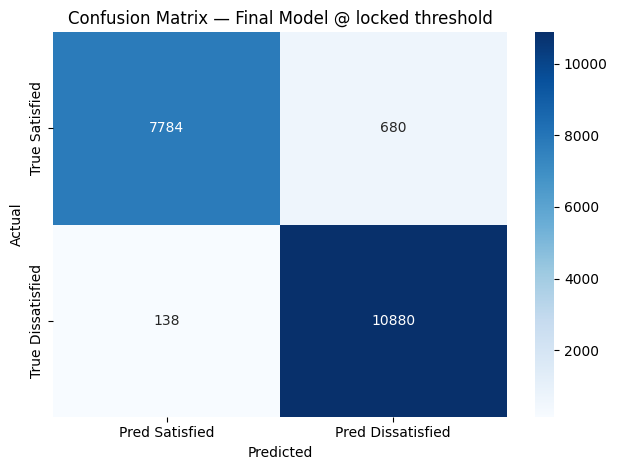

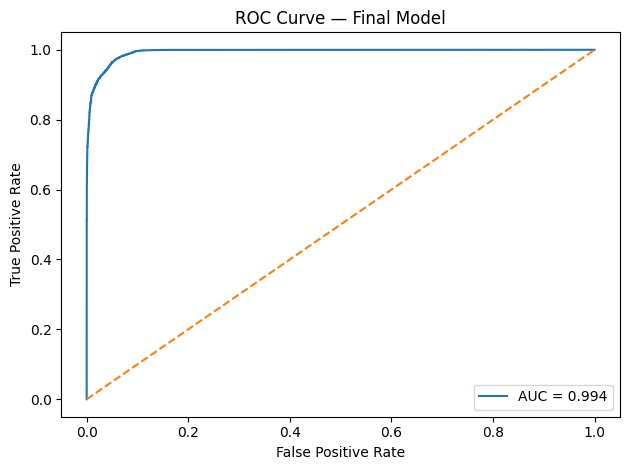

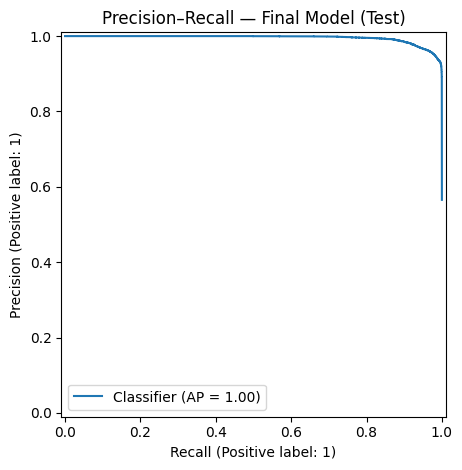

Test AP (area under PR): 0.9951


In [ ]:
final_model = best_model
final_threshold = best_threshold_keras

# 1) Probabilities and metrics at the locked threshold
y_test_proba = final_model.predict(X_test, verbose=0).ravel()
test_auc = roc_auc_score(y_test, y_test_proba)


y_test_pred = (y_test_proba >= final_threshold).astype(int)
test_f1  = f1_score(y_test, y_test_pred)
test_pr  = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)

print("=== FINAL TEST RESULTS — Final Model ===")
print(f"Threshold (locked from validation): {final_threshold:.3f}")
print(f"Test AUC: {test_auc:.4f} | F1: {test_f1:.4f} | Precision: {test_pr:.4f} | Recall: {test_rec:.4f}\n")

print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred,
                            target_names=['Satisfied','Dissatisfied']))

# 2) Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Satisfied','Pred Dissatisfied'],
            yticklabels=['True Satisfied','True Dissatisfied'])
plt.title('Confusion Matrix — Final Model @ locked threshold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

# 3) ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.plot(fpr, tpr, label=f'AUC = {test_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve — Final Model')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout(); plt.show()

# Precsion_Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba)
plt.title("Precision–Recall — Final Model (Test)")
plt.tight_layout(); plt.show()
print(f"Test AP (area under PR): {average_precision_score(y_test, y_test_proba):.4f}")


## Project Summary

**Goal**: Predict airline passenger dissatisfaction (class 1).

**Data**:
*   Preprocessed with one-hot encoding.
*   Service-rating zeros treated as missing and imputed with train medians.
*   Numeric features scaled on train only.

**Split**: 70/15/15 (train/validation/test) with stratification.

**Imbalance Handling**:
*   Compared class weighting and SMOTE.
*   Tuning used SMOTE inside CV via an imbalanced-learn Pipeline (no class weights in those runs).

**Models Evaluated**:
*   Logistic Regression
*   Random Forest
*   Small Keras NN (Dropout + EarlyStopping)

**Model Selection Metric**: Validation ROC AUC.

**Operating Threshold**: Chosen on the validation set to maximize F1 for class 1, then locked and applied to the test set.

### Final Results (Test)

*   **Final model**: Keras (Dropout, tuned)
*   **AUC**: 0.9939
*   **F1 / Precision / Recall**: 0.9638 / 0.9412 / 0.9875
*   **Threshold**: 0.35 (locked from validation)

These results indicate that the final model performs exceptionally well at predicting airline passenger dissatisfaction on the held-out test set.